In [1]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import ReduceLROnPlateau

import sys
sys.path.append('..')

from src.dataset import get_dataloaders
from src.models import get_model
from src.train import train

In [2]:
processed_dir = os.path.join('..', 'data', 'processed')
models_dir = os.path.join('..', 'outputs', 'models')
figures_dir = os.path.join('..', 'outputs', 'figures')

if not os.path.exists(models_dir):
    os.makedirs(models_dir)

if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
train_loader, val_loader, test_loader = get_dataloaders(processed_dir)

train_normal = len(os.listdir(os.path.join(processed_dir, 'train', 'NORMAL')))
train_pneumonia = len(os.listdir(os.path.join(processed_dir, 'train', 'PNEUMONIA')))
pos_weight = torch.tensor([train_normal / train_pneumonia], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

Using device: cuda


In [5]:
model_resnet = get_model('resnet50').to(device)

optimiser_resnet = torch.optim.AdamW([
    {'params': model_resnet.layer3.parameters(), 'lr': 1e-4},
    {'params': model_resnet.layer4.parameters(), 'lr': 1e-4},
    {'params': model_resnet.fc.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

scheduler_resnet = ReduceLROnPlateau(optimiser_resnet, mode='min', factor=0.1, patience=3)

history_resnet = train(
    model = model_resnet,
    train_loader = train_loader,
    val_loader = val_loader, 
    criterion = criterion, 
    optimiser = optimiser_resnet, 
    scheduler = scheduler_resnet, 
    device = device, 
    num_epochs=25,
    patience=7,
    save_path=os.path.join(models_dir, 'resnet_50.pth')
)

Trainable: 22,065,153 / 23,510,081
Epoch 1/25 | Train Loss: 0.1152 | Val Loss: 0.0787
Epoch 2/25 | Train Loss: 0.0655 | Val Loss: 0.0447
Epoch 3/25 | Train Loss: 0.0540 | Val Loss: 0.0426
Epoch 4/25 | Train Loss: 0.0334 | Val Loss: 0.0324
Epoch 5/25 | Train Loss: 0.0288 | Val Loss: 0.0504
Epoch 6/25 | Train Loss: 0.0326 | Val Loss: 0.0438
Epoch 7/25 | Train Loss: 0.0239 | Val Loss: 0.0366
Epoch 8/25 | Train Loss: 0.0189 | Val Loss: 0.0777
Epoch 9/25 | Train Loss: 0.0158 | Val Loss: 0.0402
Epoch 10/25 | Train Loss: 0.0122 | Val Loss: 0.0416
Epoch 11/25 | Train Loss: 0.0092 | Val Loss: 0.0422
Early stopping at epoch 11


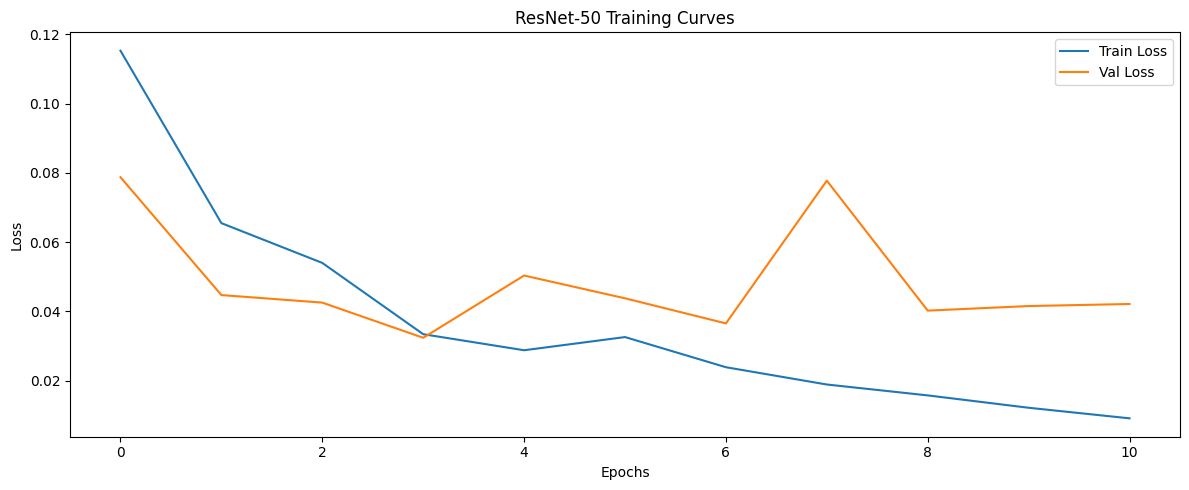

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(history_resnet['train_loss'], label='Train Loss')
plt.plot(history_resnet['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet-50 Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'resnet_50_training_curves.png'))
plt.show()

In [7]:
del model_resnet
torch.cuda.empty_cache()

In [8]:
model_densenet = get_model('densenet121').to(device)

optimiser_densenet = torch.optim.AdamW([
    {'params': model_densenet.features.denseblock3.parameters(), 'lr': 1e-4},
    {'params': model_densenet.features.transition3.parameters(), 'lr': 1e-4},
    {'params': model_densenet.features.denseblock4.parameters(), 'lr': 1e-4},
    {'params': model_densenet.features.norm5.parameters(), 'lr': 1e-4},
    {'params': model_densenet.classifier.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

scheduler_densenet = ReduceLROnPlateau(optimiser_densenet, mode='min', factor=0.1, patience=3)

history_densenet = train(
    model = model_densenet,
    train_loader = train_loader,
    val_loader = val_loader, 
    criterion = criterion, 
    optimiser = optimiser_densenet, 
    scheduler = scheduler_densenet, 
    device = device, 
    num_epochs=25,
    patience=7,
    save_path=os.path.join(models_dir, 'densenet_121.pth')
)

Trainable: 5,525,249 / 6,954,881
Epoch 1/25 | Train Loss: 0.1047 | Val Loss: 0.0821
Epoch 2/25 | Train Loss: 0.0549 | Val Loss: 0.0335
Epoch 3/25 | Train Loss: 0.0423 | Val Loss: 0.0366
Epoch 4/25 | Train Loss: 0.0416 | Val Loss: 0.0375
Epoch 5/25 | Train Loss: 0.0354 | Val Loss: 0.0356
Epoch 6/25 | Train Loss: 0.0360 | Val Loss: 0.0375
Epoch 7/25 | Train Loss: 0.0176 | Val Loss: 0.0304
Epoch 8/25 | Train Loss: 0.0191 | Val Loss: 0.0299
Epoch 9/25 | Train Loss: 0.0118 | Val Loss: 0.0310
Epoch 10/25 | Train Loss: 0.0138 | Val Loss: 0.0323
Epoch 11/25 | Train Loss: 0.0139 | Val Loss: 0.0372
Epoch 12/25 | Train Loss: 0.0120 | Val Loss: 0.0309
Epoch 13/25 | Train Loss: 0.0137 | Val Loss: 0.0339
Epoch 14/25 | Train Loss: 0.0114 | Val Loss: 0.0332
Epoch 15/25 | Train Loss: 0.0143 | Val Loss: 0.0339
Early stopping at epoch 15


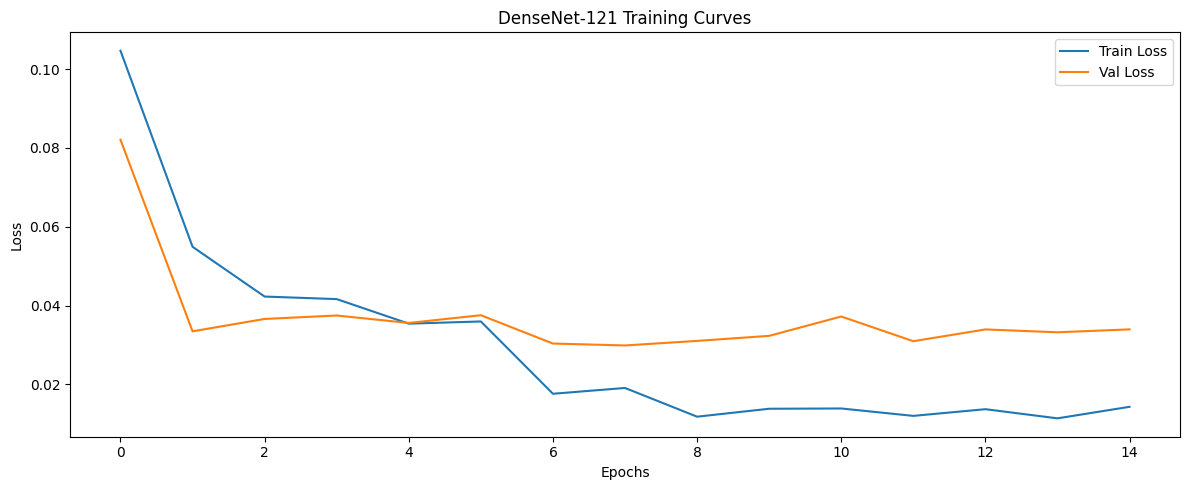

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(history_densenet['train_loss'], label='Train Loss')
plt.plot(history_densenet['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('DenseNet-121 Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'densenet_121_training_curves.png'))
plt.show()

In [10]:
del model_densenet
torch.cuda.empty_cache()

In [11]:
model_efficientnet = get_model('efficientnet_b0').to(device)

optimiser_efficientnet = torch.optim.AdamW([
    {'params': model_efficientnet.features[5].parameters(), 'lr': 1e-4},
    {'params': model_efficientnet.features[6].parameters(), 'lr': 1e-4},
    {'params': model_efficientnet.features[7].parameters(), 'lr': 1e-4},
    {'params': model_efficientnet.features[8].parameters(), 'lr': 1e-4},
    {'params': model_efficientnet.classifier.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

scheduler_efficientnet = ReduceLROnPlateau(optimiser_efficientnet, mode='min', factor=0.1, patience=3)

history_efficientnet = train(
    model = model_efficientnet,
    train_loader = train_loader,
    val_loader = val_loader, 
    criterion = criterion, 
    optimiser = optimiser_efficientnet, 
    scheduler = scheduler_efficientnet, 
    device = device, 
    num_epochs=25,
    patience=7,
    save_path=os.path.join(models_dir, 'efficientnet_b0.pth')
)

Trainable: 3,700,169 / 4,008,829
Epoch 1/25 | Train Loss: 0.1269 | Val Loss: 0.0688
Epoch 2/25 | Train Loss: 0.0726 | Val Loss: 0.0492
Epoch 3/25 | Train Loss: 0.0593 | Val Loss: 0.0442
Epoch 4/25 | Train Loss: 0.0422 | Val Loss: 0.0380
Epoch 5/25 | Train Loss: 0.0418 | Val Loss: 0.0404
Epoch 6/25 | Train Loss: 0.0339 | Val Loss: 0.0525
Epoch 7/25 | Train Loss: 0.0353 | Val Loss: 0.0358
Epoch 8/25 | Train Loss: 0.0291 | Val Loss: 0.0406
Epoch 9/25 | Train Loss: 0.0227 | Val Loss: 0.0477
Epoch 10/25 | Train Loss: 0.0265 | Val Loss: 0.0753
Epoch 11/25 | Train Loss: 0.0364 | Val Loss: 0.0395
Epoch 12/25 | Train Loss: 0.0193 | Val Loss: 0.0403
Epoch 13/25 | Train Loss: 0.0199 | Val Loss: 0.0423
Epoch 14/25 | Train Loss: 0.0172 | Val Loss: 0.0401
Early stopping at epoch 14


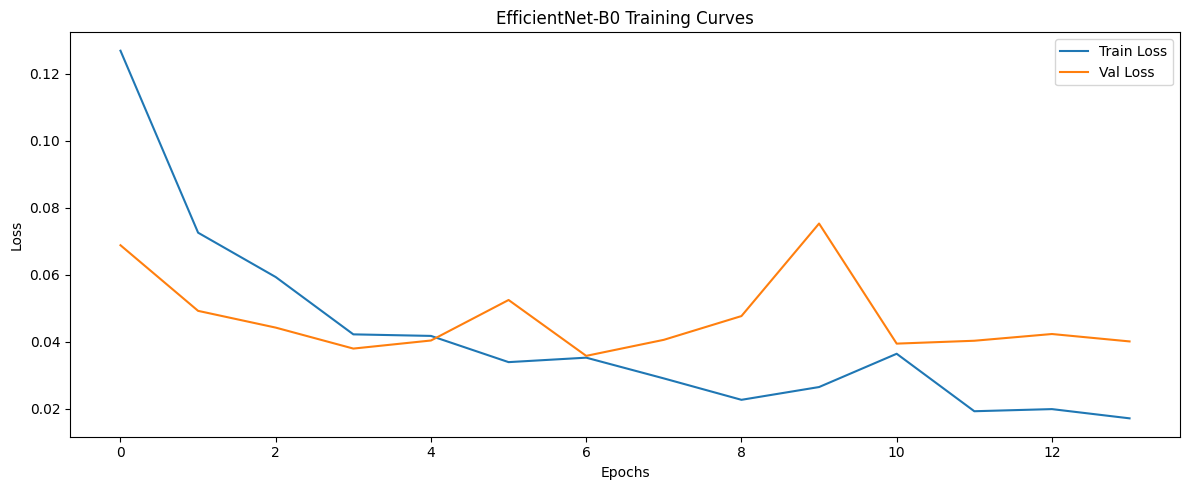

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(history_efficientnet['train_loss'], label='Train Loss')
plt.plot(history_efficientnet['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('EfficientNet-B0 Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'efficientnet_b0_training_curves.png'))
plt.show()

In [13]:
del model_efficientnet
torch.cuda.empty_cache()

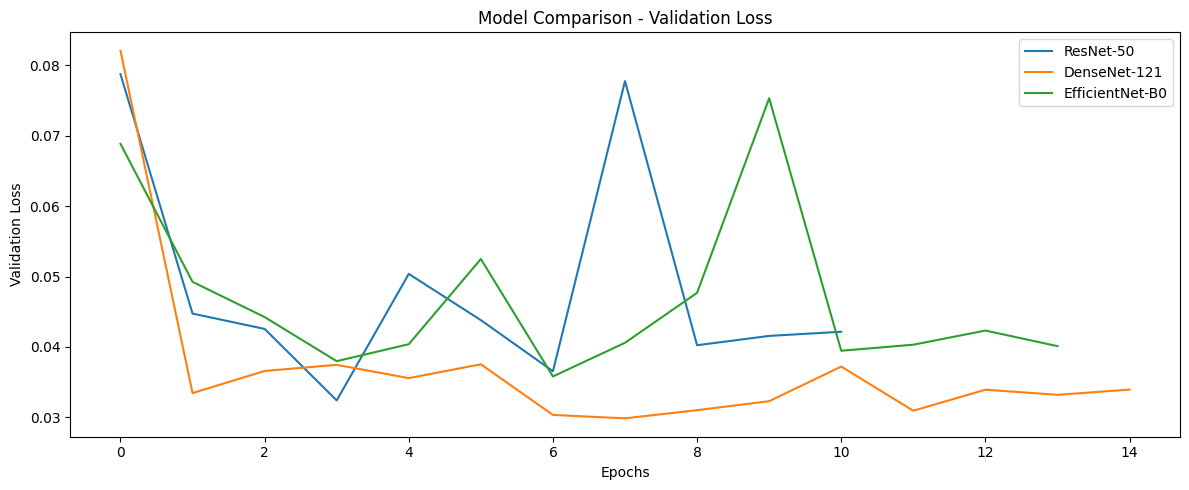

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(history_resnet['val_loss'], label='ResNet-50')
plt.plot(history_densenet['val_loss'], label='DenseNet-121')
plt.plot(history_efficientnet['val_loss'], label='EfficientNet-B0')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Model Comparison - Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'model_comparison.png'))
plt.show()